In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/alirezaderavi98/predicting-stock-prices-tsla/TSLA.csv


In [2]:
# Load Libraries

# Data handling
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#ML
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.feature_selection import mutual_info_regression
import shap
from sklearn.metrics import silhouette_score

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, StackingRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import ttest_rel


In [3]:
# Load Data

data_path = '/kaggle/input/datasets/alirezaderavi98/predicting-stock-prices-tsla/TSLA.csv'

# Load datasets
data = pd.read_csv(data_path)

# Display shapes
print("Data Shape:", data.shape)

# Preview
data.head()


Data Shape: (1258, 7)


,Date,Open,High,Low,Close,Adj Close,Volume
0,8/16/2016,45.098000,45.438000,44.681999,44.722000,44.722000,11335500
1,8/17/2016,44.866001,44.966000,44.560001,44.647999,44.647999,8935500
2,8/18/2016,44.764000,45.132000,44.458000,44.702000,44.702000,8572500
3,8/19/2016,44.708000,45.034000,44.506001,45.000000,45.000000,8297500
4,8/22/2016,44.834000,45.021999,44.535999,44.585999,44.585999,10327500



--- Missing Values ---
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

--- Duplicate Rows ---
0
Remaining missing values: 0
Duplicates removed.
Data types fixed.
Before removing outliers:


/tmp/ipykernel_16/3888347958.py:45: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


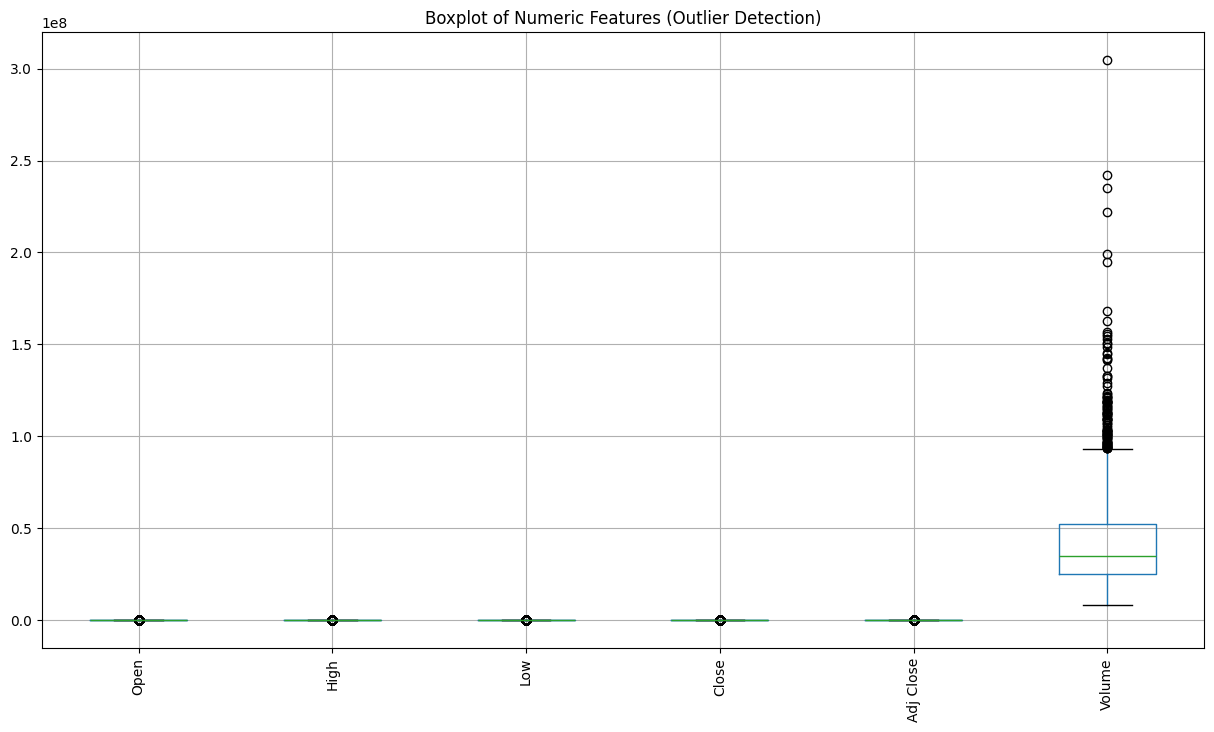

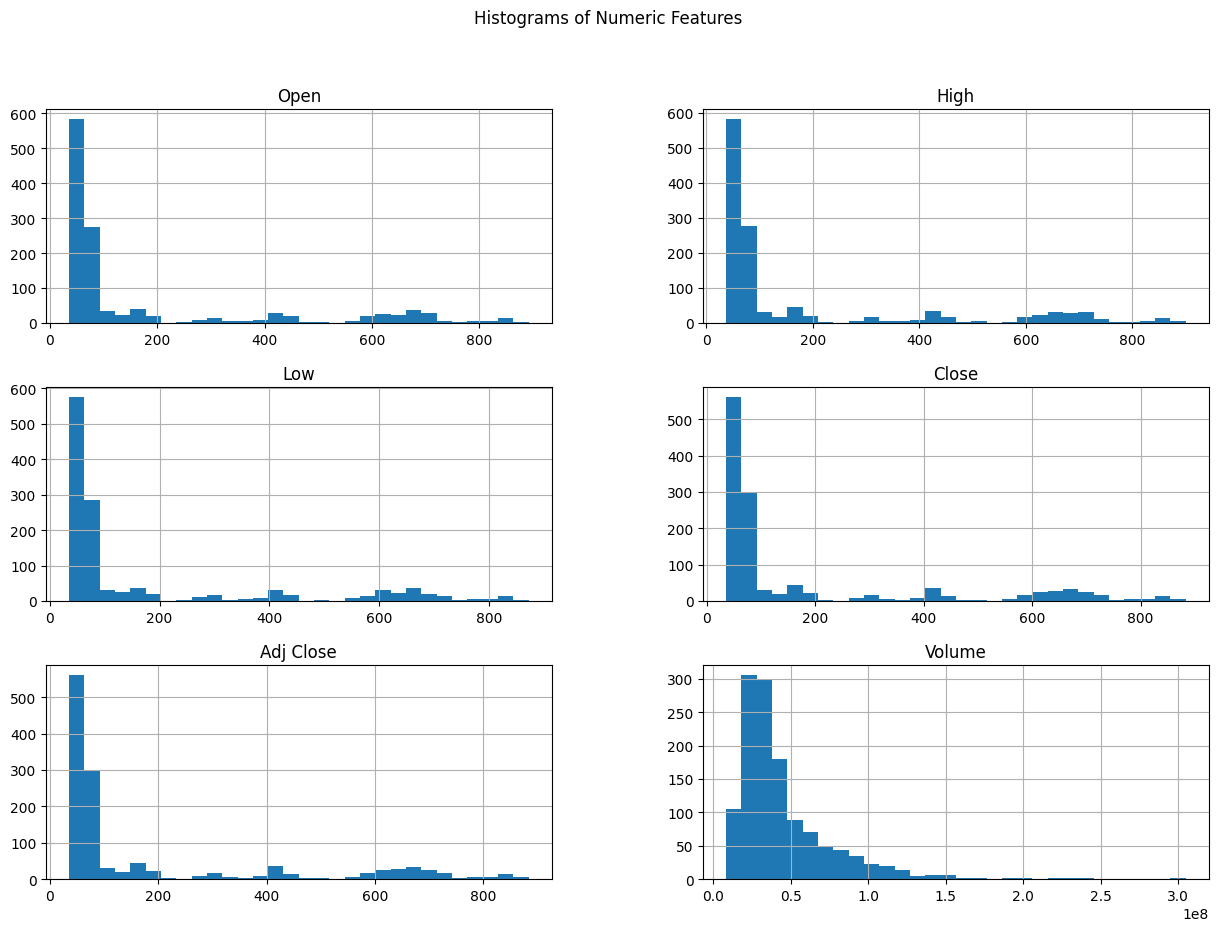

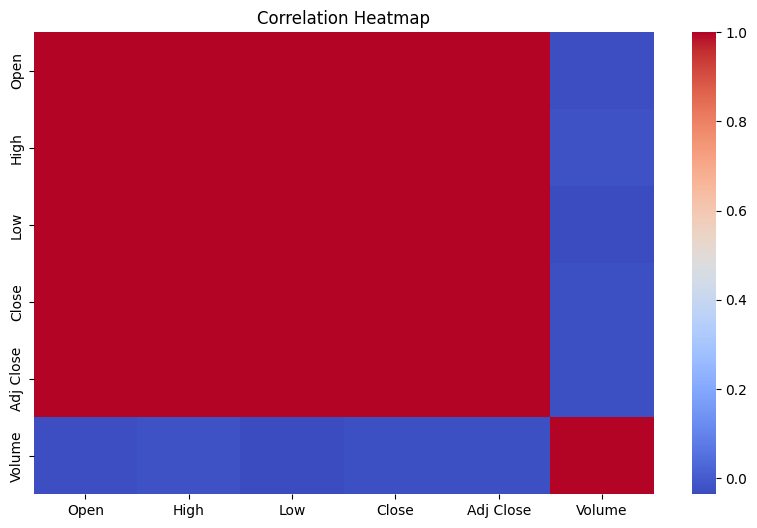

Outliers removed. Remaining rows: 921
After removing outliers:


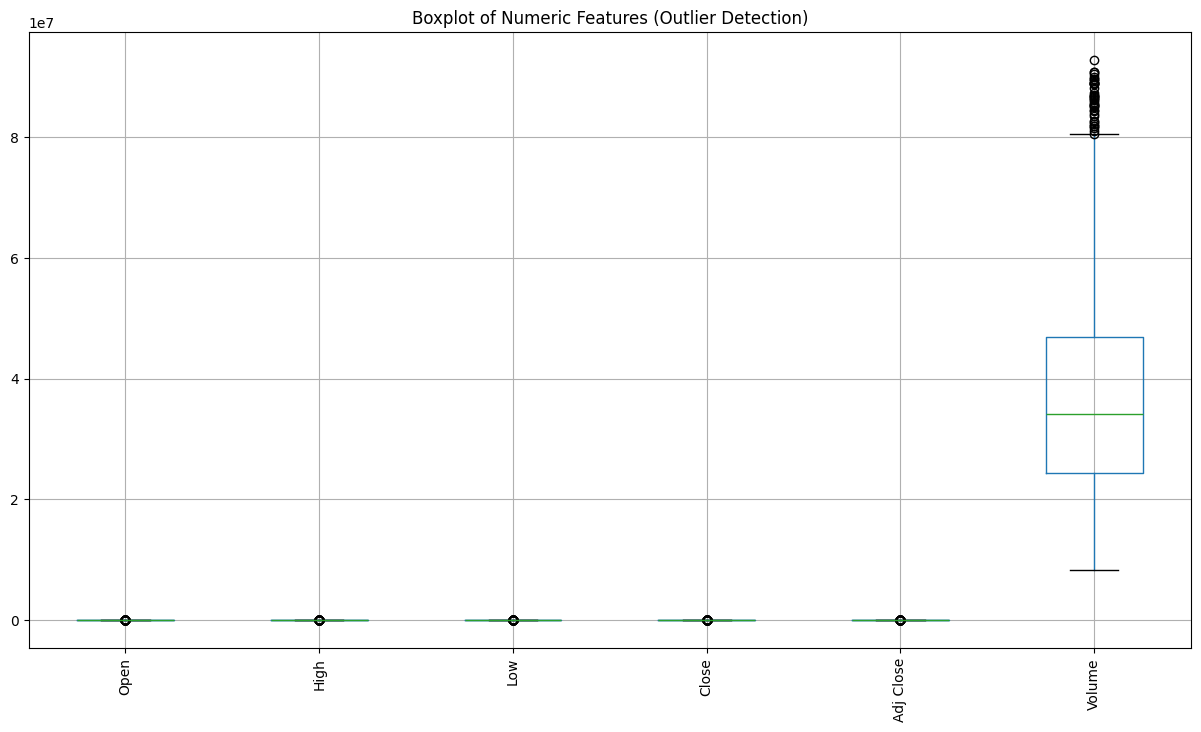

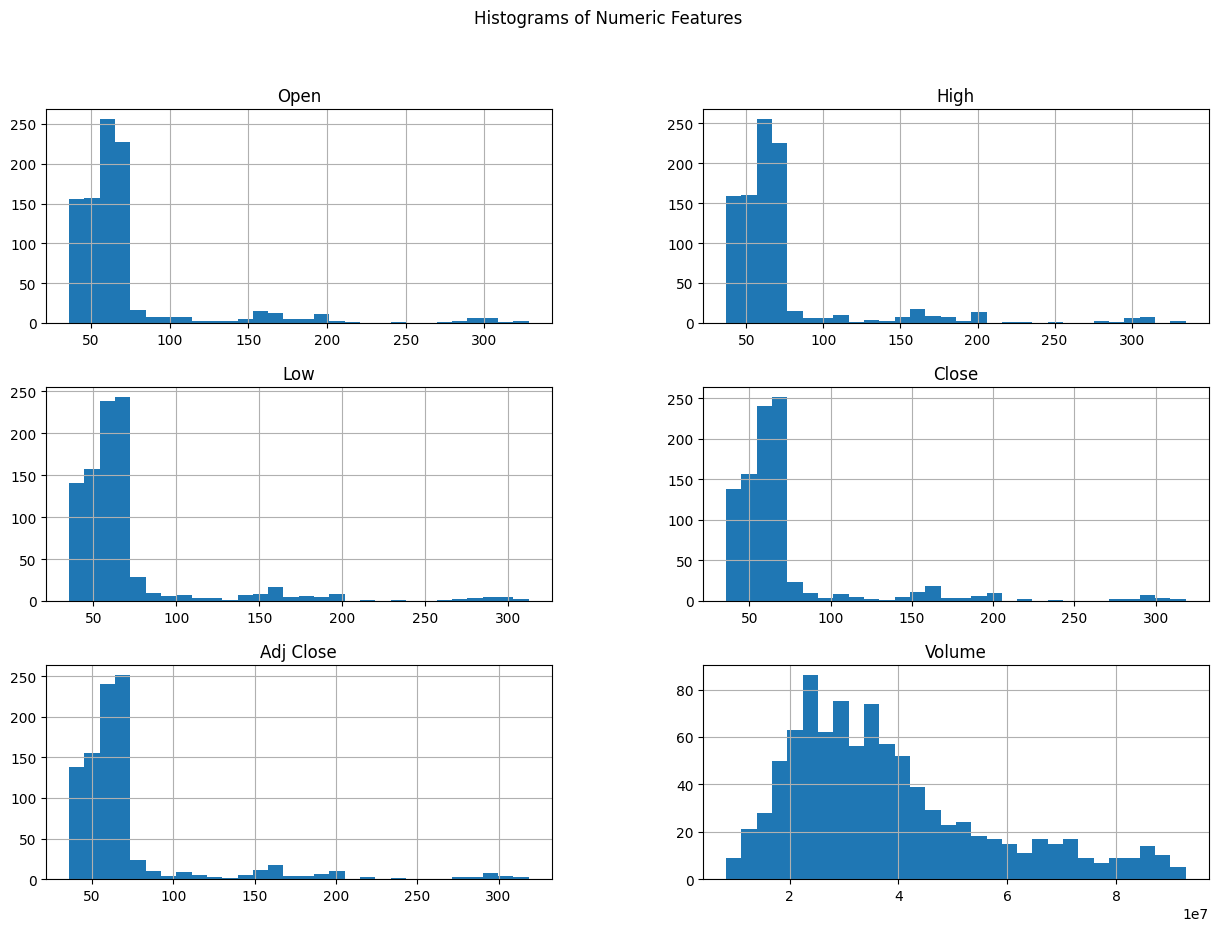

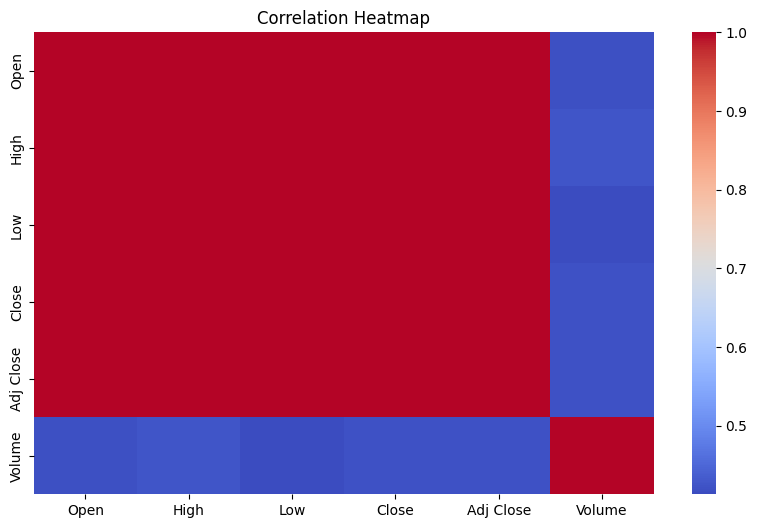

Data normalized safely.
Cleaned data saved to /kaggle/working/cleaned_data_train.csv


,Date,Open,High,Low,Close,Adj Close,Volume
0,8/16/2016,0.030428,0.028491,0.033516,0.031584,0.031584,0.035944
1,8/17/2016,0.029633,0.026908,0.033076,0.031323,0.031323,0.007549
2,8/18/2016,0.029284,0.027465,0.032707,0.031514,0.031514,0.003254
3,8/19/2016,0.029092,0.027136,0.032881,0.032568,0.032568,0.000000
4,8/22/2016,0.029524,0.027096,0.032989,0.031103,0.031103,0.024018


In [4]:
# Cleaning process

def data_overview(df):
    # Count missing values
    missing = df.isnull().sum()
    print("\n--- Missing Values ---")
    print(missing)

    if(missing.sum() > 0):
        # Filter columns with missing values
        missing = missing[missing > 0].sort_values(ascending=False)

        # Plot bar chart
        plt.figure(figsize=(12,6))
        missing.plot(kind='bar')

        plt.title('Missing Values per Column')
        plt.xlabel('Features')
        plt.ylabel('Number of Missing Values')

        plt.show()
        
    print("\n--- Duplicate Rows ---")
    print(df.duplicated().sum().sum())

    return df

# =========================
# Handle Missing Values
# =========================
def handle_missing_values(df):

    # 1. Replace common fake missing values with actual NaN
    df = df.replace(
    ["NA", "N/A", "null", "?", "", "None", "nan", "NaN", " "],
    np.nan)
    

    # 2. Drop columns with more than 50% missing values
    threshold = len(df) * 0.5
    df = df.dropna(thresh=threshold, axis=1)

    # 3. Attempt to convert columns to numeric where possible
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='ignore')

    # Identify numeric and categorical columns
    num_cols = df.select_dtypes(include=np.number).columns
    cat_cols = df.select_dtypes(include='object').columns

    # 4. Fill missing values in numeric columns with mean
    df.loc[:, num_cols] = df[num_cols].fillna(df[num_cols].mean())

    # 5. Fill missing values in categorical columns
    for col in cat_cols:
        if df[col].mode().empty:
            # If no mode exists (all values are NaN), fill with placeholder
            df.loc[:, col] = df[col].fillna("Unknown")
        else:
            # Fill with most frequent value
            df.loc[:, col] = df[col].fillna(df[col].mode()[0])
    
    # 7. Final check: drop any remaining missing values
    df = df.dropna()

    # Print remaining missing values (should be zero)
    print("Remaining missing values:", df.isnull().sum().sum())

    return df

# =========================
# Remove Duplicates
# =========================
def remove_duplicates(df):
    df = df.drop_duplicates()
    print("Duplicates removed.")
    return df


# =========================
# Fix Data Types
# =========================
def fix_data_types(df):
    for col in df.columns:
        try:
            df[col] = pd.to_numeric(df[col])
        except:
            pass

    print("Data types fixed.")
    return df


# =========================
# Handle Outliers (IQR)
# =========================
def remove_outliers(df):
    num_cols = df.select_dtypes(include=np.number).columns

    mask = pd.Series(True, index=df.index)

    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        mask &= df[col].between(lower_bound, upper_bound)

    df_cleaned = df[mask]

    print(f"Outliers removed. Remaining rows: {len(df_cleaned)}")
    return df_cleaned


def visualize_outliers(df):
    num_cols = df.select_dtypes(include=np.number).columns

    # 1. Boxplot
    plt.figure(figsize=(15, 8))
    df[num_cols].boxplot(rot=90)
    plt.title("Boxplot of Numeric Features (Outlier Detection)")
    plt.show()

    # 2. Histogram
    df[num_cols].hist(figsize=(15, 10), bins=30)
    plt.suptitle("Histograms of Numeric Features")
    plt.show()

    # 3. Heatmap correlation
    plt.figure(figsize=(10, 6))
    sns.heatmap(df[num_cols].corr(), cmap="coolwarm", annot=False)
    plt.title("Correlation Heatmap")
    plt.show()
    
# =========================
# Normalize Data
# =========================
def normalize_data(df):
    num_cols = df.select_dtypes(include=np.number).columns

    min_vals = df[num_cols].min()
    max_vals = df[num_cols].max()

    denom = (max_vals - min_vals).replace(0, 1)

    df[num_cols] = (df[num_cols] - min_vals) / denom

    print("Data normalized safely.")
    return df

# =========================
# Full Pipeline
# =========================
def clean_data_pipeline(df, save_path=None):
    df = data_overview(df)
    df = handle_missing_values(df)
    df = remove_duplicates(df)
    df = fix_data_types(df)
    print('Before removing outliers:')
    visualize_outliers(df)
    df = remove_outliers(df)
    print('After removing outliers:')
    visualize_outliers(df)
    df = normalize_data(df)

    if save_path:
        df.to_csv(save_path, index=False)
        print(f"Cleaned data saved to {save_path}")

    return df


cleaned_df = clean_data_pipeline(data, '/kaggle/working/cleaned_data_train.csv')

# Preview
cleaned_df.head()

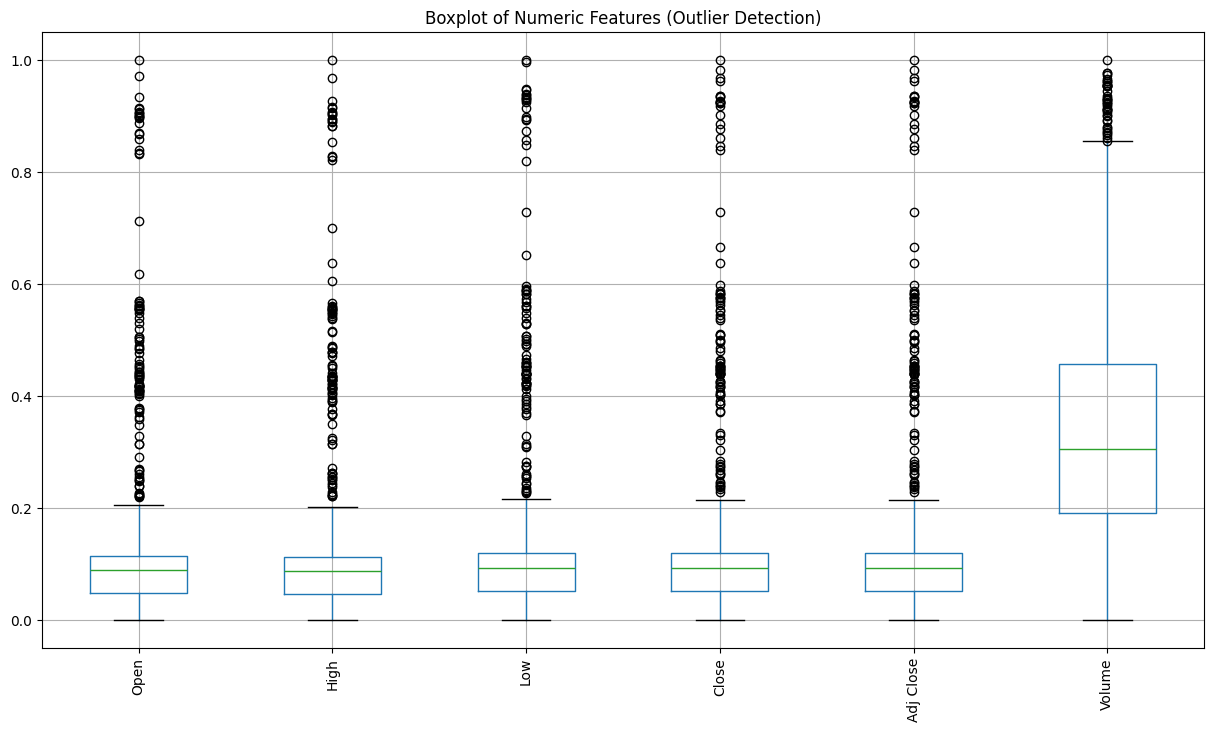

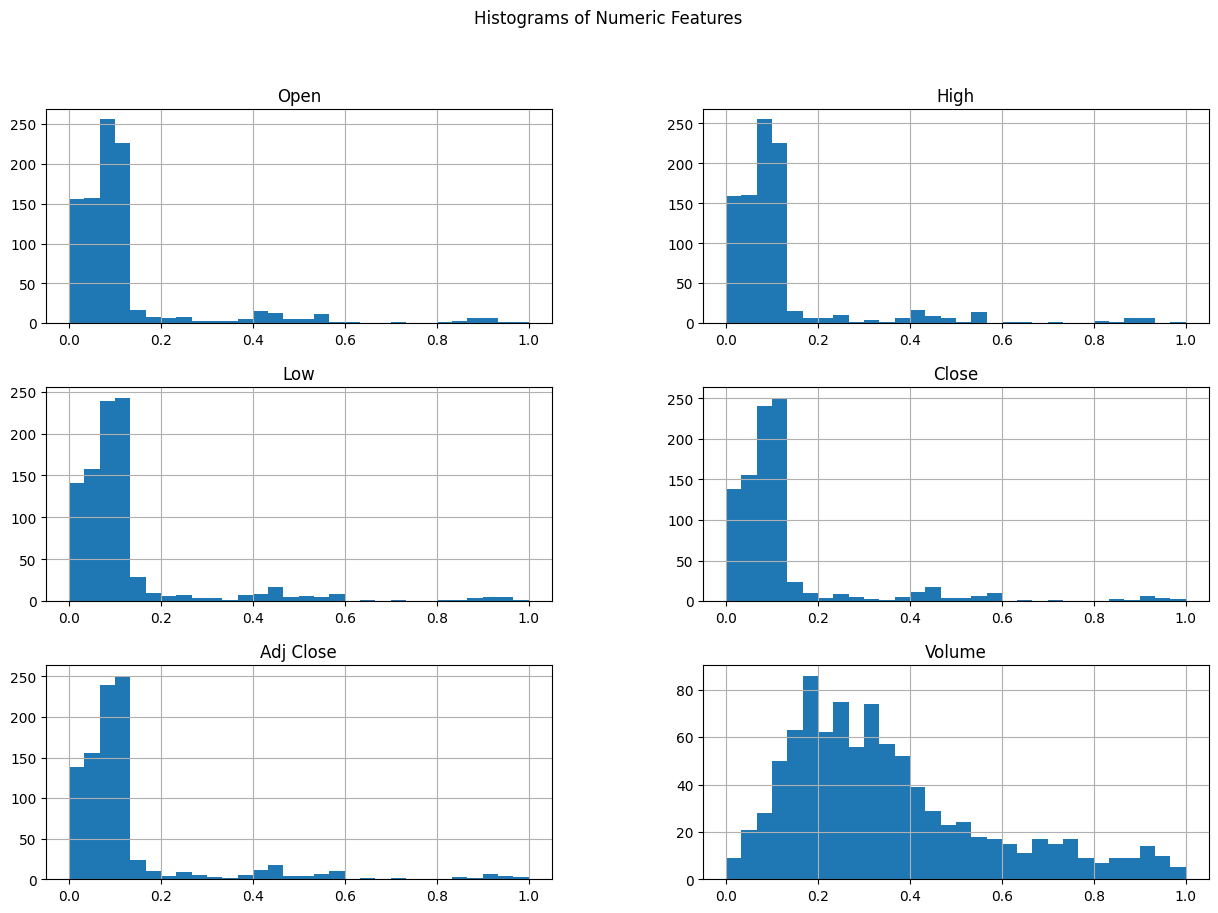

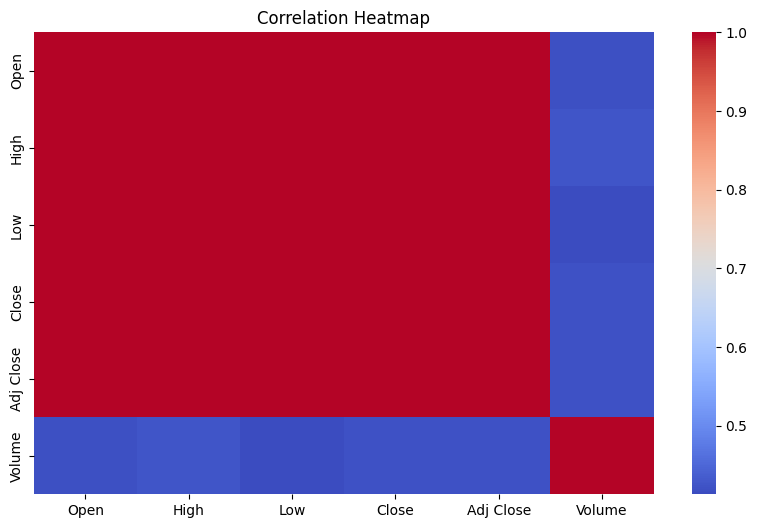

In [5]:
visualize_outliers(cleaned_df)

In [6]:
print(cleaned_df.columns)
df = cleaned_df

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


In [7]:
#Feature Engineering
df['Date'] = pd.to_datetime(df['Date'])
df['day_of_week'] = df['Date'].dt.dayofweek
df['month'] = df['Date'].dt.month
df['is_month_end'] = df['Date'].dt.is_month_end.astype(int)

df['return'] = df['Close'].pct_change()
df['hl_range'] = (df['High'] - df['Low']) / df['Close']
df['oc_diff'] = (df['Open'] - df['Close']) / df['Close']

df['close_lag1'] = df['Close'].shift(1)
df['close_lag2'] = df['Close'].shift(2)
df['volume_lag1'] = df['Volume'].shift(1)

df['ma_5'] = df['Close'].rolling(5).mean()
df['ma_20'] = df['Close'].rolling(20).mean()

df['volatility_20'] = df['Close'].rolling(20).std()

delta = df['Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss
df['rsi'] = 100 - (100 / (1 + rs))

df['volume_change'] = df['Volume'].pct_change()
df['volume_ma_10'] = df['Volume'].rolling(10).mean()

df['target'] = df['Close'].pct_change().shift(-1)

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

In [8]:
#Feature Selection

X = df.drop(["target", "Date"], axis=1)
y = df["target"]
X = pd.get_dummies(X)

#Lasso (Sparse Selection)
lasso = Lasso(alpha=0.001)
lasso.fit(X, y)

lasso_selected = X.columns[lasso.coef_ != 0]

#Mutual Information
mi = mutual_info_regression(X, y)
mi_scores = pd.Series(mi, index=X.columns)

mi_selected = mi_scores[mi_scores > mi_scores.mean()].index

#Tree-based Importance
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X, y)

rf_importance = pd.Series(rf.feature_importances_, index=X.columns)
rf_selected = rf_importance[rf_importance > rf_importance.mean()].index

#SHAP
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

shap_importance = np.abs(shap_values).mean(axis=0)
shap_selected = X.columns[shap_importance > shap_importance.mean()]

#Hybrid Selection
weights = {
    "lasso": 1,
    "mi": 1,
    "rf": 2,
    "shap": 3
}

scores = {}

for f in X.columns:
    scores[f] = 0
    if f in lasso_selected: scores[f] += weights["lasso"]
    if f in mi_selected: scores[f] += weights["mi"]
    if f in rf_selected: scores[f] += weights["rf"]
    if f in shap_selected: scores[f] += weights["shap"]

final_features = [f for f, s in scores.items() if s >= 3]
print(final_features)

['High', 'Low', 'Adj Close', 'hl_range', 'oc_diff', 'volume_lag1', 'ma_20', 'volatility_20', 'rsi']


Stacking Validation:
RMSE: 0.11111410156138239
MAE: 0.06420216020914017
R2: -0.1902623537968846


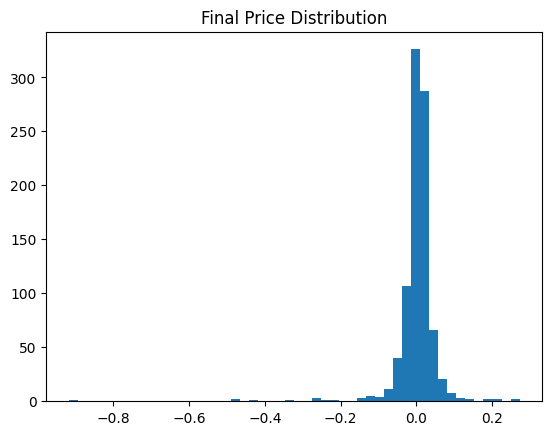

In [9]:
# =========================
# Evaluation function
# =========================
def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2


# =========================
# Data preparation
# =========================
X = X[final_features]

# =========================
# Time-based split 
# =========================
split = int(len(X) * 0.8)

X_train, X_val = X.iloc[:split], X.iloc[split:]
y_train, y_val = y.iloc[:split], y.iloc[split:]


# =========================
# Scaling 
# =========================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)


# =========================
# Base models
# =========================
ridge = Ridge()
rf = RandomForestRegressor(n_estimators=200, random_state=42)
xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42)

estimators = [
    ('ridge', ridge),
    ('rf', rf),
    ('xgb', xgb)
]


# =========================
# Stacking model
# =========================
stack_model = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression()
)


# =========================
# Train stacking
# =========================
stack_model.fit(X_train_scaled, y_train)


# =========================
# Validation
# =========================
pred_stack_val = stack_model.predict(X_val_scaled)

rmse, mae, r2 = evaluate(y_val, pred_stack_val)

print("Stacking Validation:")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)


# =========================
# Final training (full data)
# =========================
X_scaled = scaler.fit_transform(X)
stack_model.fit(X_scaled, y)


# =========================
# Prediction
# =========================
final_pred = stack_model.predict(X_scaled)


# =========================
# Visualization
# =========================
plt.figure()
plt.hist(final_pred, bins=50)
plt.title("Final Price Distribution")
plt.show()

In [10]:
# =========================
# Individual models evaluation
# =========================

models = {
    "Ridge": ridge,
    "RandomForest": rf,
    "XGBoost": xgb,
    "Stacking": stack_model
}

results = {}

for name, model in models.items():
    
    # Train
    if name == "Stacking":
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_val_scaled)
    else:
        # برای Ridge از scaled استفاده کن
        if name == "Ridge":
            model.fit(X_train_scaled, y_train)
            pred = model.predict(X_val_scaled)
        else:
            # RF و XGB نیازی به scaling ندارن
            model.fit(X_train, y_train)
            pred = model.predict(X_val)
    
    rmse, mae, r2 = evaluate(y_val, pred)
    
    results[name] = {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

# =========================
# Print results
# =========================
for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    print("RMSE:", metrics["RMSE"])
    print("MAE:", metrics["MAE"])
    print("R2:", metrics["R2"])


Ridge:
RMSE: 0.13221979159855804
MAE: 0.08717525557528397
R2: -0.6853778280957781

RandomForest:
RMSE: 0.11037295728680947
MAE: 0.06765936989481616
R2: -0.1744369261824723

XGBoost:
RMSE: 0.10438101431434949
MAE: 0.0622763032460692
R2: -0.0503822283170976

Stacking:
RMSE: 0.11111410156138239
MAE: 0.06420216020914017
R2: -0.1902623537968846


In [11]:
naive_pred = np.zeros_like(y_val)  

rmse_naive = np.sqrt(mean_squared_error(y_val, naive_pred))
print("Naive RMSE:", rmse_naive)

Naive RMSE: 0.10393040222313182
